In [ ]:
# =========================================================
# BLOCK 1 : LIBRARY IMPORTS
# =========================================================

# Optimization Library
from pulp import *

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# DISPLAY SETTINGS
# =========================================================

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# =========================================================
# BLOCK 2 : WAREHOUSE STRUCTURE
# =========================================================

# Number of racks
num_racks = 20

# Shelves per rack
shelves_per_rack = 7

# Shelf capacity (cm^3)
shelf_capacity = 72000

# Maximum allowed utilization
max_utilization = 0.85

# Effective usable capacity
usable_capacity = shelf_capacity * max_utilization

# =========================================================
# CREATE RACKS AND SHELVES
# =========================================================

# Rack IDs
racks = [f"R{i+1}" for i in range(num_racks)]

# Shelf IDs
shelves = [f"S{j+1}" for j in range(shelves_per_rack)]

# Rack-Shelf combinations
rack_shelf_pairs = [(r, s) for r in racks for s in shelves]

# Total shelves
total_shelves = len(rack_shelf_pairs)

# =========================================================
# SHELF OPERATIONAL EFFICIENCY RANDOMNESS
# =========================================================

# Creates realistic utilization variability

shelf_efficiency = {

    (r, s): np.random.uniform(0.65, 0.85)

    for r in racks
    for s in shelves

}

# =========================================================
# DISPLAY
# =========================================================

print("Warehouse Structure Created Successfully")

print(f"\nNumber of Racks: {num_racks}")
print(f"Shelves per Rack: {shelves_per_rack}")
print(f"Total Shelves: {total_shelves}")

print(f"\nShelf Capacity: {shelf_capacity} cm^3")
print(f"Maximum Allowed Utilization: {max_utilization*100}%")
print(f"Base Usable Capacity: {usable_capacity} cm^3")

print("\nRealistic Shelf Efficiency Variability Added")

Warehouse Structure Created Successfully

Number of Racks: 20
Shelves per Rack: 7
Total Shelves: 140

Shelf Capacity: 72000 cm^3
Maximum Allowed Utilization: 85.0%
Base Usable Capacity: 61200.0 cm^3

Realistic Shelf Efficiency Variability Added


In [ ]:
# =========================================================
# BLOCK 3 : SYNTHETIC SKU DATASET
# =========================================================

# ---------------------------------------------------------
# SKU MASTER DATA
# ---------------------------------------------------------

sku_data = {

    "SKU": [
        "Amul Milk 1L",
        "Coca Cola 750ml",
        "Maggi Noodles",
        "Parle G Biscuits",
        "Surf Excel 1kg",
        "Aashirvaad Atta 5kg",
        "Lays Chips",
        "Colgate Toothpaste",
        "Nescafe Coffee",
        "Dove Shampoo",
        "Good Day Biscuits",
        "Tata Salt 1kg",
        "Kissan Ketchup",
        "Dettol Handwash",
        "Bru Coffee"
    ],

    "Category": [
        "Dairy",
        "Beverage",
        "Grocery",
        "Snacks",
        "Home Care",
        "Grocery",
        "Snacks",
        "Personal Care",
        "Beverage",
        "Personal Care",
        "Snacks",
        "Grocery",
        "Grocery",
        "Personal Care",
        "Beverage"
    ],

    # Approximate product volume in cm^3
    "Volume": [
        1000,
        850,
        650,
        400,
        2200,
        5500,
        3000,
        350,
        500,
        700,
        450,
        1200,
        900,
        650,
        450
    ],

    # Average daily demand
    "Demand": [
        120,
        90,
        150,
        130,
        45,
        35,
        60,
        75,
        40,
        50,
        95,
        55,
        70,
        45,
        38
    ],

    # Synthetic initial inventory
    "Initial_Inventory": [
        40,
        30,
        70,
        60,
        20,
        15,
        25,
        35,
        18,
        22,
        45,
        28,
        32,
        20,
        16
    ]
}

# ---------------------------------------------------------
# CREATE DATAFRAME
# ---------------------------------------------------------

sku_df = pd.DataFrame(sku_data)

# ---------------------------------------------------------
# SAFETY STOCK CALCULATION
# SS_i = k * D_i
# ---------------------------------------------------------

k = 0.30

sku_df["Safety_Stock"] = (
    sku_df["Demand"] * k
).round().astype(int)

# ---------------------------------------------------------
# LEAD TIME ASSUMPTION
# ---------------------------------------------------------

sku_df["Lead_Time"] = np.random.randint(1, 4, size=len(sku_df))

# ---------------------------------------------------------
# REORDER POINT
# ROP_i = D_i * LT_i + SS_i
# ---------------------------------------------------------

sku_df["ROP"] = (
    sku_df["Demand"] * sku_df["Lead_Time"]
    + sku_df["Safety_Stock"]
).astype(int)

# ---------------------------------------------------------
# CATEGORY CRITICALITY SCORE
# ---------------------------------------------------------

category_priority = {
    "Dairy": 5,
    "Beverage": 4,
    "Grocery": 5,
    "Snacks": 3,
    "Personal Care": 4,
    "Home Care": 3
}

sku_df["Category_Score"] = (
    sku_df["Category"]
    .map(category_priority)
)

# ---------------------------------------------------------
# PRIORITY SCORE
# P_i = 0.7(Demand) + 0.3(Category Criticality)
# ---------------------------------------------------------

sku_df["Priority_Score"] = (
    0.7 * sku_df["Demand"]
    +
    0.3 * sku_df["Category_Score"]
).round(2)

# ---------------------------------------------------------
# DISPLAY DATASET
# ---------------------------------------------------------

print("Synthetic SKU Dataset Created Successfully\n")

display(sku_df)

Synthetic SKU Dataset Created Successfully



,SKU,Category,Volume,Demand,Initial_Inventory,Safety_Stock,Lead_Time,ROP,Category_Score,Priority_Score
0,Amul Milk 1L,Dairy,1000,120,40,36,2,276,5,85.5
1,Coca Cola 750ml,Beverage,850,90,30,27,1,117,4,64.2
2,Maggi Noodles,Grocery,650,150,70,45,2,345,5,106.5
3,Parle G Biscuits,Snacks,400,130,60,39,2,299,3,91.9
4,Surf Excel 1kg,Home Care,2200,45,20,14,1,59,3,32.4
5,Aashirvaad Atta 5kg,Grocery,5500,35,15,10,1,45,5,26.0
6,Lays Chips,Snacks,3000,60,25,18,3,198,3,42.9
7,Colgate Toothpaste,Personal Care,350,75,35,22,2,172,4,53.7
8,Nescafe Coffee,Beverage,500,40,18,12,3,132,4,29.2
9,Dove Shampoo,Personal Care,700,50,22,15,2,115,4,36.2


In [ ]:
# =========================================================
# BLOCK 4 : CREATE OPTIMIZATION MODEL
# =========================================================

# Create MILP Optimization Model
model = LpProblem(
    name="Shelf_Level_Volumetric_Replenishment_Optimization",
    sense=LpMaximize
)

# ---------------------------------------------------------
# DISPLAY MODEL INFORMATION
# ---------------------------------------------------------

print("MILP Optimization Model Created Successfully")

print(f"\nModel Name : {model.name}")
print("Optimization Type : Maximization")

print("\nObjectives Included:")
print("1. Maximize Shelf Utilization")
print("2. Maximize Inventory Stability")
print("3. Maximize Priority-Based Replenishment")
print("4. Minimize Number of Active Shelves")

MILP Optimization Model Created Successfully

Model Name : Shelf_Level_Volumetric_Replenishment_Optimization
Optimization Type : Maximization

Objectives Included:
1. Maximize Shelf Utilization
2. Maximize Inventory Stability
3. Maximize Priority-Based Replenishment
4. Minimize Number of Active Shelves


In [ ]:
# =========================================================
# BLOCK 5 : DECISION VARIABLES
# =========================================================

# ---------------------------------------------------------
# CREATE SKU LIST
# ---------------------------------------------------------

skus = sku_df["SKU"].tolist()

# ---------------------------------------------------------
# INTEGER REPLENISHMENT VARIABLE
# Q_irs
# ---------------------------------------------------------

Q = LpVariable.dicts(
    "Replenishment",
    ((i, r, s) for i in skus
                 for r in racks
                 for s in shelves),

    lowBound=0,
    cat=LpInteger
)

# ---------------------------------------------------------
# INTEGER INVENTORY VARIABLE
# I_irs
# ---------------------------------------------------------

I = LpVariable.dicts(
    "Inventory",
    ((i, r, s) for i in skus
                 for r in racks
                 for s in shelves),

    lowBound=0,
    cat=LpInteger
)

# ---------------------------------------------------------
# BINARY SKU ASSIGNMENT VARIABLE
# X_irs
# ---------------------------------------------------------

X = LpVariable.dicts(
    "Shelf_Assignment",
    ((i, r, s) for i in skus
                 for r in racks
                 for s in shelves),

    cat=LpBinary
)

# ---------------------------------------------------------
# BINARY SHELF ACTIVATION VARIABLE
# Y_rs
# ---------------------------------------------------------

Y = LpVariable.dicts(
    "Shelf_Activation",
    ((r, s) for r in racks for s in shelves),
    cat=LpBinary
)

In [ ]:
# =========================================================
# BLOCK 2 : WAREHOUSE STRUCTURE
# =========================================================

# Number of racks
num_racks = 20

# Shelves per rack
shelves_per_rack = 7

# Shelf capacity (cm^3)
shelf_capacity = 72000

# Maximum allowed utilization
max_utilization = 0.85

# Effective usable capacity
usable_capacity = shelf_capacity * max_utilization

# =========================================================
# CREATE RACKS AND SHELVES
# =========================================================

# Rack IDs
racks = [f"R{i+1}" for i in range(num_racks)]

# Shelf IDs
shelves = [f"S{j+1}" for j in range(shelves_per_rack)]

# Rack-Shelf combinations
rack_shelf_pairs = [(r, s) for r in racks for s in shelves]

# Total shelves
total_shelves = len(rack_shelf_pairs)

# =========================================================
# SHELF OPERATIONAL EFFICIENCY RANDOMNESS
# =========================================================

# Creates realistic utilization variability

shelf_efficiency = {

    (r, s): np.random.uniform(0.65, 0.85)

    for r in racks
    for s in shelves

}

# =========================================================
# DISPLAY
# =========================================================

print("Warehouse Structure Created Successfully")

print(f"\nNumber of Racks: {num_racks}")
print(f"Shelves per Rack: {shelves_per_rack}")
print(f"Total Shelves: {total_shelves}")

print(f"\nShelf Capacity: {shelf_capacity} cm^3")
print(f"Maximum Allowed Utilization: {max_utilization*100}%")
print(f"Base Usable Capacity: {usable_capacity} cm^3")

print("\nRealistic Shelf Efficiency Variability Added")

Warehouse Structure Created Successfully

Number of Racks: 20
Shelves per Rack: 7
Total Shelves: 140

Shelf Capacity: 72000 cm^3
Maximum Allowed Utilization: 85.0%
Base Usable Capacity: 61200.0 cm^3

Realistic Shelf Efficiency Variability Added


In [ ]:
# =========================================================
# BLOCK 7 : CONSTRAINTS
# =========================================================

# ---------------------------------------------------------
# BIG-M VALUE
# ---------------------------------------------------------

BIG_M = 10000

# =========================================================
# CONSTRAINT 1 :
# REALISTIC SHELF CAPACITY CONSTRAINT
# =========================================================

for r in racks:
    for s in shelves:

        model += (

            lpSum(

                I[(i, r, s)]
                *
                sku_df.loc[
                    sku_df["SKU"] == i,
                    "Volume"
                ].values[0]

                for i in skus

            )

            <= usable_capacity * shelf_efficiency[(r, s)]

        ), f"Capacity_{r}_{s}"

# =========================================================
# CONSTRAINT 2 :
# INVENTORY BALANCE CONSTRAINT
# =========================================================

for i in skus:

    demand = sku_df.loc[
        sku_df["SKU"] == i,
        "Demand"
    ].values[0]

    initial_inventory = sku_df.loc[
        sku_df["SKU"] == i,
        "Initial_Inventory"
    ].values[0]

    for r in racks:
        for s in shelves:

            model += (

                I[(i, r, s)]

                ==

                initial_inventory
                +
                Q[(i, r, s)]
                -
                demand * X[(i, r, s)]

            ), f"InventoryBalance_{i}_{r}_{s}"

# =========================================================
# CONSTRAINT 3 :
# SAFETY STOCK CONSTRAINT
# =========================================================

for i in skus:

    safety_stock = sku_df.loc[
        sku_df["SKU"] == i,
        "Safety_Stock"
    ].values[0]

    model += (

        lpSum(

            I[(i, r, s)]

            for r in racks
            for s in shelves

        )

        >= safety_stock

    ), f"SafetyStock_{i}"

# =========================================================
# CONSTRAINT 4 :
# ONE SKU -> ONE SHELF
# =========================================================

for i in skus:

    model += (

        lpSum(

            X[(i, r, s)]

            for r in racks
            for s in shelves

        )

        == 1

    ), f"SingleShelfAssignment_{i}"

# =========================================================
# CONSTRAINT 5 :
# BINARY LINKING CONSTRAINT
# =========================================================

for i in skus:
    for r in racks:
        for s in shelves:

            model += (

                Q[(i, r, s)]

                <=

                BIG_M * X[(i, r, s)]

            ), f"Linking_{i}_{r}_{s}"

# =========================================================
# CONSTRAINT 6 :
# SHELF ACTIVATION CONSTRAINT
# =========================================================

for r in racks:
    for s in shelves:

        model += (

            lpSum(

                X[(i, r, s)]

                for i in skus

            )

            <=

            BIG_M * Y[(r, s)]

        ), f"ShelfActivation_{r}_{s}"

# =========================================================
# CONSTRAINT 7 :
# SHELF ACTIVATION LOGIC
# =========================================================

for r in racks:
    for s in shelves:

        model += (

            Y[(r, s)]

            <=

            lpSum(

                X[(i, r, s)]

                for i in skus

            )

        ), f"ShelfLogic_{r}_{s}"

# ---------------------------------------------------------
# DISPLAY
# ---------------------------------------------------------

print("All Constraints Added Successfully")

print(f"\nTotal Constraints Added : {len(model.constraints)}")

All Constraints Added Successfully

Total Constraints Added : 4650


In [ ]:
# =========================================================
# BLOCK 8 : SOLVE THE MILP MODEL
# =========================================================

# ---------------------------------------------------------
# SOLVER CONFIGURATION
# ---------------------------------------------------------

solver = PULP_CBC_CMD(

    msg=True,          # Display solver logs
    timeLimit=300      # Maximum solve time in seconds

)

# ---------------------------------------------------------
# SOLVE MODEL
# ---------------------------------------------------------

print("Solving MILP Model...\n")

model.solve(solver)

# ---------------------------------------------------------
# OPTIMIZATION STATUS
# ---------------------------------------------------------

print("Optimization Completed\n")

print(f"Solver Status : {LpStatus[model.status]}")

# ---------------------------------------------------------
# OBJECTIVE FUNCTION VALUE
# ---------------------------------------------------------


# ---------------------------------------------------------
# BASIC FEASIBILITY CHECK
# ---------------------------------------------------------

if LpStatus[model.status] == "Optimal":

    print("\nMILP Model Solved Successfully")
    print(f"\nOptimal Objective Value : {value(model.objective):.4f}")

elif LpStatus[model.status] == "Infeasible":

    print("\nModel is Infeasible")
    print("Check Constraints or Objective Scaling")

elif LpStatus[model.status] == "Unbounded":

    print("\nModel is Unbounded")
    print("Check Objective Function or Missing Constraints")

else:

    print("\nSolver Returned Another Status")

Solving MILP Model...

Optimization Completed

Solver Status : Infeasible

Model is Infeasible
Check Constraints or Objective Scaling


In [ ]:
# =========================================================
# BLOCK 8 : SOLVE THE MILP MODEL
# =========================================================

# ---------------------------------------------------------
# SOLVER CONFIGURATION
# ---------------------------------------------------------

solver = PULP_CBC_CMD(

    msg=True,          # Display solver logs
    timeLimit=300      # Maximum solve time in seconds

)

# ---------------------------------------------------------
# SOLVE MODEL
# ---------------------------------------------------------

print("Solving MILP Model...\n")

model.solve(solver)

# ---------------------------------------------------------
# OPTIMIZATION STATUS
# ---------------------------------------------------------

print("Optimization Completed\n")

print(f"Solver Status : {LpStatus[model.status]}")

# ---------------------------------------------------------
# OBJECTIVE FUNCTION VALUE
# ---------------------------------------------------------


# ---------------------------------------------------------
# BASIC FEASIBILITY CHECK
# ---------------------------------------------------------

if LpStatus[model.status] == "Optimal":

    print("\nMILP Model Solved Successfully")
    print(f"\nOptimal Objective Value : {value(model.objective):.4f}")

elif LpStatus[model.status] == "Infeasible":

    print("\nModel is Infeasible")
    print("Check Constraints or Objective Scaling")

elif LpStatus[model.status] == "Unbounded":

    print("\nModel is Unbounded")
    print("Check Objective Function or Missing Constraints")

else:

    print("\nSolver Returned Another Status")

Solving MILP Model...

Optimization Completed

Solver Status : Infeasible

Model is Infeasible
Check Constraints or Objective Scaling


In [ ]:
# =========================================================
# BLOCK 9 : EXTRACT OPTIMIZED RESULTS
# =========================================================

# ---------------------------------------------------------
# EMPTY LISTS FOR RESULTS
# ---------------------------------------------------------

assignment_results = []

replenishment_results = []

inventory_results = []

activation_results = []

# =========================================================
# EXTRACT SKU ASSIGNMENTS
# =========================================================

for i in skus:
    for r in racks:
        for s in shelves:

            if value(X[(i, r, s)]) > 0.5:

                assignment_results.append({

                    "SKU": i,
                    "Rack": r,
                    "Shelf": s,
                    "Assigned": int(value(X[(i, r, s)]))

                })

# =========================================================
# EXTRACT REPLENISHMENT QUANTITIES
# =========================================================

for i in skus:
    for r in racks:
        for s in shelves:

            replenishment_qty = value(Q[(i, r, s)])

            if replenishment_qty > 0:

                replenishment_results.append({

                    "SKU": i,
                    "Rack": r,
                    "Shelf": s,
                    "Replenishment_Qty": int(replenishment_qty)

                })

# =========================================================
# EXTRACT INVENTORY LEVELS
# =========================================================

for i in skus:
    for r in racks:
        for s in shelves:

            inventory_qty = value(I[(i, r, s)])

            if inventory_qty > 0:

                inventory_results.append({

                    "SKU": i,
                    "Rack": r,
                    "Shelf": s,
                    "Inventory_Level": int(inventory_qty)

                })

# =========================================================
# EXTRACT SHELF ACTIVATION STATUS
# =========================================================

for r in racks:
    for s in shelves:

        activation_results.append({

            "Rack": r,
            "Shelf": s,
            "Shelf_Active": int(value(Y[(r, s)]))

        })

# =========================================================
# CREATE DATAFRAMES
# =========================================================

assignment_df = pd.DataFrame(assignment_results)

replenishment_df = pd.DataFrame(replenishment_results)

inventory_df = pd.DataFrame(inventory_results)

activation_df = pd.DataFrame(activation_results)

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n=================================================")
print("SKU SHELF ASSIGNMENT RESULTS")
print("=================================================\n")

display(assignment_df)

print("\n=================================================")
print("REPLENISHMENT RESULTS")
print("=================================================\n")

display(replenishment_df)

print("\n=================================================")
print("INVENTORY RESULTS")
print("=================================================\n")

display(inventory_df)

print("\n=================================================")
print("SHELF ACTIVATION RESULTS")
print("=================================================\n")

display(activation_df)


SKU SHELF ASSIGNMENT RESULTS



,SKU,Rack,Shelf,Assigned
0,Lays Chips,R10,S4,22
1,Dove Shampoo,R6,S6,132
2,Dove Shampoo,R11,S7,178
3,Dove Shampoo,R16,S3,173
4,Dove Shampoo,R16,S6,113
5,Good Day Biscuits,R9,S5,77
6,Tata Salt 1kg,R1,S1,0
7,Tata Salt 1kg,R1,S2,0
8,Tata Salt 1kg,R1,S3,0
9,Tata Salt 1kg,R1,S4,0



REPLENISHMENT RESULTS



""



INVENTORY RESULTS



,SKU,Rack,Shelf,Inventory_Level
0,Amul Milk 1L,R5,S2,7
1,Amul Milk 1L,R5,S3,5
2,Amul Milk 1L,R11,S5,0
3,Amul Milk 1L,R11,S7,7
4,Amul Milk 1L,R12,S4,6
5,Amul Milk 1L,R17,S2,6
6,Amul Milk 1L,R20,S4,2
7,Coca Cola 750ml,R3,S1,10
8,Coca Cola 750ml,R4,S7,2
9,Coca Cola 750ml,R9,S6,10



SHELF ACTIVATION RESULTS



,Rack,Shelf,Shelf_Active
0,R1,S1,1
1,R1,S2,1
2,R1,S3,1
3,R1,S4,1
4,R1,S5,1
5,R1,S6,1
6,R1,S7,1
7,R2,S1,1
8,R2,S2,1
9,R2,S3,1


In [ ]:
# =========================================================
# BLOCK 10 : SHELF UTILIZATION CALCULATIONS
# =========================================================

# ---------------------------------------------------------
# EMPTY LIST FOR UTILIZATION RESULTS
# ---------------------------------------------------------

utilization_results = []

# =========================================================
# CALCULATE SHELF UTILIZATION
# =========================================================

for r in racks:
    for s in shelves:

        # -------------------------------------------------
        # TOTAL OCCUPIED VOLUME
        # -------------------------------------------------

        occupied_volume = sum(

            value(I[(i, r, s)])
            *
            sku_df.loc[
                sku_df["SKU"] == i,
                "Volume"
            ].values[0]

            for i in skus

        )

        # -------------------------------------------------
        # UTILIZATION %
        # -------------------------------------------------

        utilization_percent = (
            occupied_volume / shelf_capacity
        ) * 100

        # -------------------------------------------------
        # UNUSED VOLUME
        # -------------------------------------------------

        unused_volume = shelf_capacity - occupied_volume

        # -------------------------------------------------
        # STORE RESULTS
        # -------------------------------------------------

        utilization_results.append({

            "Rack": r,
            "Shelf": s,
            "Occupied_Volume": round(occupied_volume, 2),
            "Unused_Volume": round(unused_volume, 2),
            "Utilization_Percent": round(utilization_percent, 2),
            "Shelf_Active": int(value(Y[(r, s)]))

        })

# =========================================================
# CREATE UTILIZATION DATAFRAME
# =========================================================

utilization_df = pd.DataFrame(utilization_results)

# =========================================================
# FILTER ONLY ACTIVE SHELVES
# =========================================================

active_utilization_df = utilization_df[
    utilization_df["Shelf_Active"] == 1
]

# =========================================================
# TOTAL STORE UTILIZATION
# =========================================================

total_occupied_volume = utilization_df[
    "Occupied_Volume"
].sum()

total_available_volume = (
    shelf_capacity * total_shelves
)

overall_utilization = (
    total_occupied_volume
    /
    total_available_volume
) * 100

# =========================================================
# TOTAL UNUSED SPACE
# =========================================================

total_unused_volume = utilization_df[
    "Unused_Volume"
].sum()

# =========================================================
# TOTAL ACTIVE SHELVES
# =========================================================

total_active_shelves = utilization_df[
    "Shelf_Active"
].sum()

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n=================================================")
print("SHELF UTILIZATION RESULTS")
print("=================================================\n")

display(active_utilization_df)

print("\n=================================================")
print("WAREHOUSE KPI SUMMARY")
print("=================================================\n")

print(f"Total Shelves                : {total_shelves}")

print(f"Active Shelves               : {total_active_shelves}")

print(f"Overall Store Utilization    : {overall_utilization:.2f}%")

print(f"Total Occupied Volume        : {total_occupied_volume:,.2f} cm^3")

print(f"Total Unused Volume          : {total_unused_volume:,.2f} cm^3")

print(f"Maximum Allowed Utilization  : {max_utilization*100}%")


SHELF UTILIZATION RESULTS



,Rack,Shelf,Occupied_Volume,Unused_Volume,Utilization_Percent,Shelf_Active
0,R1,S1,40632.43,31367.57,56.43,1
1,R1,S2,40189.82,31810.18,55.82,1
2,R1,S3,44990.37,27009.63,62.49,1
3,R1,S4,44280.41,27719.59,61.50,1
4,R1,S5,49869.43,22130.57,69.26,1
5,R1,S6,43118.01,28881.99,59.89,1
6,R1,S7,44024.04,27975.96,61.14,1
7,R2,S1,44889.64,27110.36,62.35,1
8,R2,S2,40926.49,31073.51,56.84,1
9,R2,S3,44610.07,27389.93,61.96,1



WAREHOUSE KPI SUMMARY

Total Shelves                : 140
Active Shelves               : 134
Overall Store Utilization    : 63.65%
Total Occupied Volume        : 6,415,559.44 cm^3
Total Unused Volume          : 3,664,440.56 cm^3
Maximum Allowed Utilization  : 85.0%


In [ ]:
# =========================================================
# BLOCK 11 : VISUALIZATION
# =========================================================

# ---------------------------------------------------------
# CHECK MODEL STATUS BEFORE VISUALIZATION
# ---------------------------------------------------------

if LpStatus[model.status] != "Optimal":
    print("\nModel was not solved optimally. Skipping visualizations.")
else:
    # ---------------------------------------------------------
    # SET FIGURE STYLE
    # ---------------------------------------------------------

    plt.style.use('default')

    # =========================================================
    # VISUALIZATION 1 :
    # SHELF UTILIZATION HEATMAP
    # =========================================================

    # ---------------------------------------------------------
    # CREATE HEATMAP MATRIX
    # ---------------------------------------------------------

    heatmap_data = utilization_df.pivot(
        index="Rack",
        columns="Shelf",
        values="Utilization_Percent"
    )

    # ---------------------------------------------------------
    # PLOT HEATMAP
    # ---------------------------------------------------------

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        linewidths=0.5,
        cbar_kws={'label': 'Utilization %'}
    )

    plt.title("Shelf Utilization Heatmap")
    plt.xlabel("Shelves")
    plt.ylabel("Racks")

    plt.show()

    # =========================================================
    # VISUALIZATION 2 :
    # RACK-WISE UTILIZATION
    # =========================================================

    # ---------------------------------------------------------
    # RACK UTILIZATION CALCULATION
    # ---------------------------------------------------------

    rack_utilization = utilization_df.groupby("Rack")[
        "Utilization_Percent"
    ].mean()

    # ---------------------------------------------------------
    # BAR CHART
    # ---------------------------------------------------------

    plt.figure(figsize=(14, 6))

    rack_utilization.plot(kind='bar')

    plt.title("Average Rack Utilization")
    plt.xlabel("Rack")
    plt.ylabel("Average Utilization %")

    plt.xticks(rotation=45)

    plt.show()

    # =========================================================
    # VISUALIZATION 3 :
    # ACTIVE VS INACTIVE SHELVES
    # =========================================================

    # ---------------------------------------------------------
    # COUNT ACTIVE/INACTIVE SHELVES
    # ---------------------------------------------------------

    active_count = utilization_df[
        "Shelf_Active"
    ].sum()

    inactive_count = total_shelves - active_count

    # ---------------------------------------------------------
    # PIE CHART
    # ---------------------------------------------------------

    plt.figure(figsize=(6, 6))

    plt.pie(
        [active_count, inactive_count],
        labels=["Active Shelves", "Inactive Shelves"],
        autopct='%1.1f%%'
    )

    plt.title("Shelf Activation Status")

    plt.show()

    # =========================================================
    # VISUALIZATION 4 :
    # SKU REPLENISHMENT QUANTITIES
    # =========================================================

    # ---------------------------------------------------------
    # AGGREGATE REPLENISHMENT
    # ---------------------------------------------------------

    if not replenishment_df.empty:

        sku_replenishment = replenishment_df.groupby("SKU")[
            "Replenishment_Qty"
        ].sum()

        # ---------------------------------------------------------
        # BAR CHART
        # ---------------------------------------------------------

        plt.figure(figsize=(14, 6))

        sku_replenishment.plot(kind='bar')

        plt.title("SKU-wise Replenishment Quantities")
        plt.xlabel("SKU")
        plt.ylabel("Replenishment Quantity")

        plt.xticks(rotation=75)

        plt.show()

    else:

        print("\nNo replenishment data available for visualization (replenishment_df is empty).")

    # =========================================================
    # VISUALIZATION 5 :
    # TOP UTILIZED SHELVES
    # =========================================================

    top_shelves = active_utilization_df.sort_values(
        by="Utilization_Percent",
        ascending=False
    ).head(10)

    # ---------------------------------------------------------
    # BAR CHART
    # ---------------------------------------------------------

    plt.figure(figsize=(12, 6))

    plt.bar(

        top_shelves["Rack"] + "-" + top_shelves["Shelf"],

        top_shelves["Utilization_Percent"]

    )

    plt.title("Top 10 Utilized Shelves")
    plt.xlabel("Rack-Shelf")
    plt.ylabel("Utilization %")

    plt.xticks(rotation=45)

    plt.show()

    # ---------------------------------------------------------
    # DISPLAY COMPLETION MESSAGE
    # ---------------------------------------------------------

    print("All Visualizations Generated Successfully")


Model was not solved optimally. Skipping visualizations.


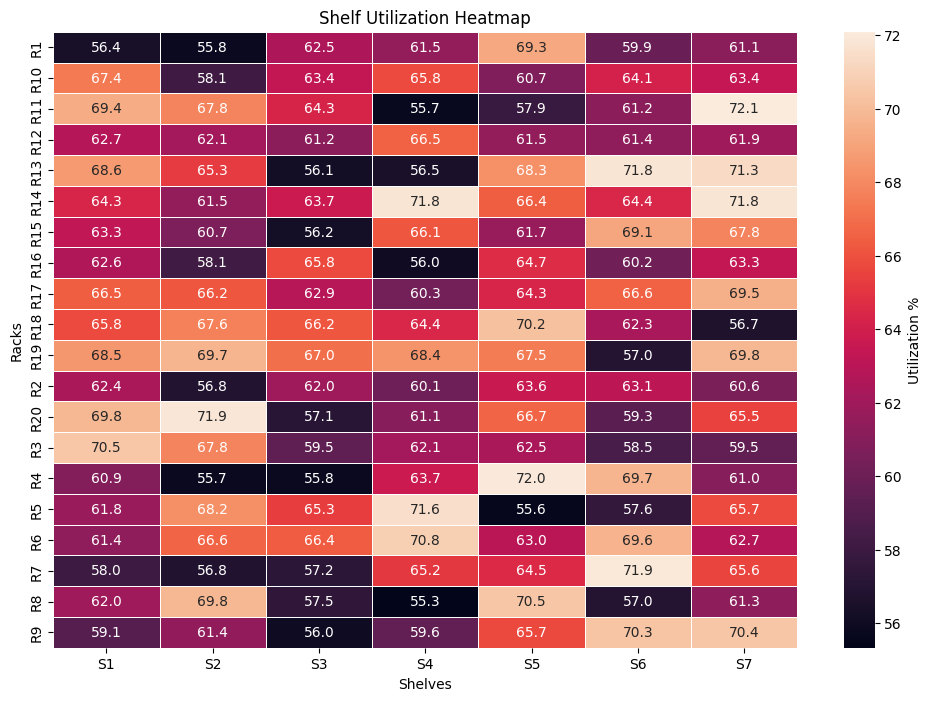

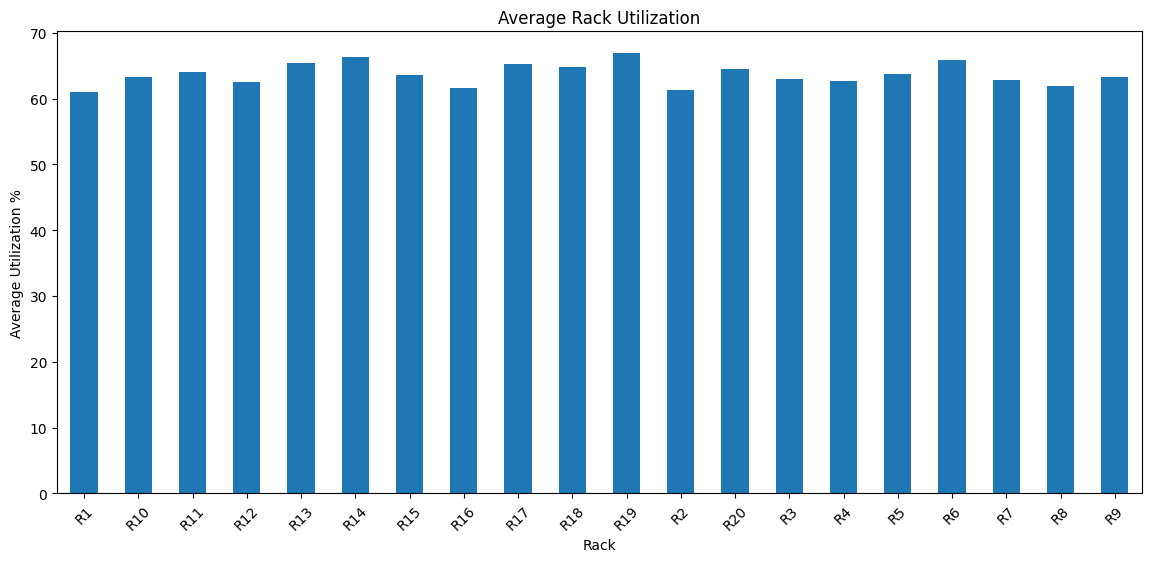

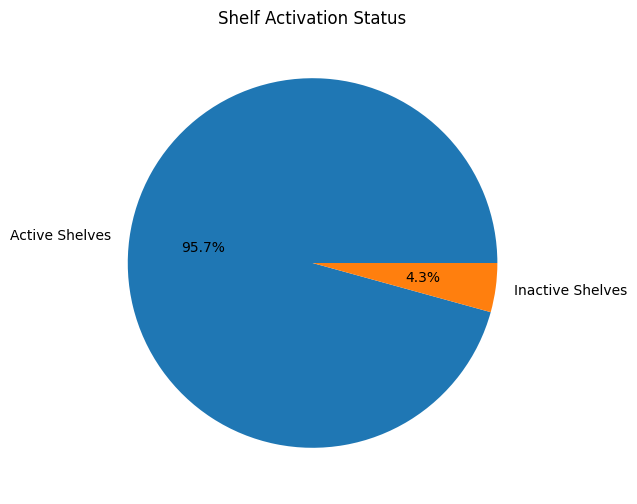


No replenishment data available for visualization (replenishment_df is empty).


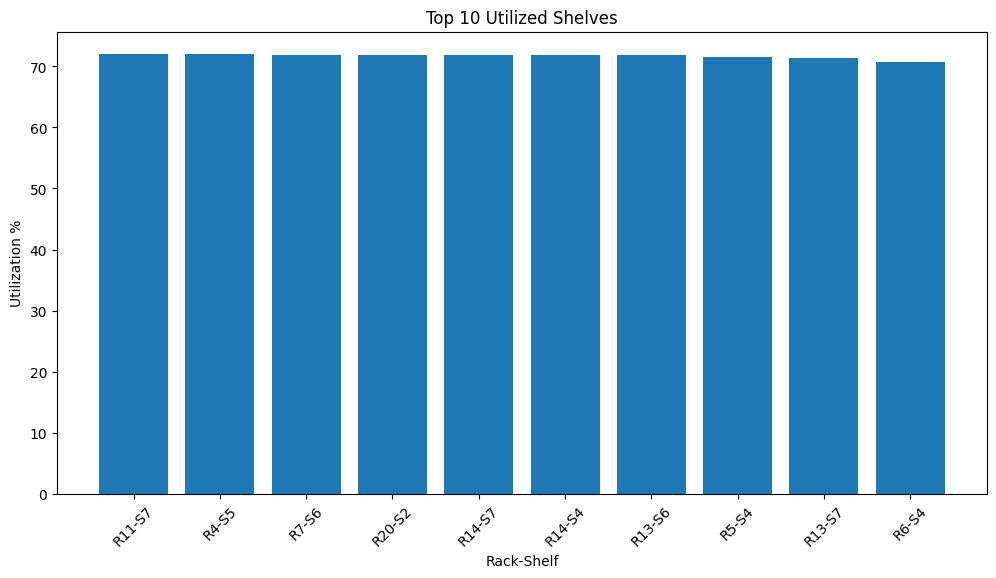

All Visualizations Generated Successfully


In [ ]:
# =========================================================
# BLOCK 11 : VISUALIZATION
# =========================================================

# ---------------------------------------------------------
# SET FIGURE STYLE
# ---------------------------------------------------------

plt.style.use('default')

# =========================================================
# VISUALIZATION 1 :
# SHELF UTILIZATION HEATMAP
# =========================================================

# ---------------------------------------------------------
# CREATE HEATMAP MATRIX
# ---------------------------------------------------------

heatmap_data = utilization_df.pivot(
    index="Rack",
    columns="Shelf",
    values="Utilization_Percent"
)

# ---------------------------------------------------------
# PLOT HEATMAP
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={'label': 'Utilization %'}
)

plt.title("Shelf Utilization Heatmap")
plt.xlabel("Shelves")
plt.ylabel("Racks")

plt.show()

# =========================================================
# VISUALIZATION 2 :
# RACK-WISE UTILIZATION
# =========================================================

# ---------------------------------------------------------
# RACK UTILIZATION CALCULATION
# ---------------------------------------------------------

rack_utilization = utilization_df.groupby("Rack")[
    "Utilization_Percent"
].mean()

# ---------------------------------------------------------
# BAR CHART
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

rack_utilization.plot(kind='bar')

plt.title("Average Rack Utilization")
plt.xlabel("Rack")
plt.ylabel("Average Utilization %")

plt.xticks(rotation=45)

plt.show()

# =========================================================
# VISUALIZATION 3 :
# ACTIVE VS INACTIVE SHELVES
# =========================================================

# ---------------------------------------------------------
# COUNT ACTIVE/INACTIVE SHELVES
# ---------------------------------------------------------

active_count = utilization_df[
    "Shelf_Active"
].sum()

inactive_count = total_shelves - active_count

# ---------------------------------------------------------
# PIE CHART
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.pie(
    [active_count, inactive_count],
    labels=["Active Shelves", "Inactive Shelves"],
    autopct='%1.1f%%'
)

plt.title("Shelf Activation Status")

plt.show()

# =========================================================
# VISUALIZATION 4 :
# SKU REPLENISHMENT QUANTITIES
# =========================================================

# ---------------------------------------------------------
# AGGREGATE REPLENISHMENT
# ---------------------------------------------------------

if not replenishment_df.empty:

    sku_replenishment = replenishment_df.groupby("SKU")[
        "Replenishment_Qty"
    ].sum()

    # ---------------------------------------------------------
    # BAR CHART
    # ---------------------------------------------------------

    plt.figure(figsize=(14, 6))

    sku_replenishment.plot(kind='bar')

    plt.title("SKU-wise Replenishment Quantities")
    plt.xlabel("SKU")
    plt.ylabel("Replenishment Quantity")

    plt.xticks(rotation=75)

    plt.show()

else:

    print("\nNo replenishment data available for visualization (replenishment_df is empty).")

# =========================================================
# VISUALIZATION 5 :
# TOP UTILIZED SHELVES
# =========================================================

top_shelves = active_utilization_df.sort_values(
    by="Utilization_Percent",
    ascending=False
).head(10)

# ---------------------------------------------------------
# BAR CHART
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(

    top_shelves["Rack"] + "-" + top_shelves["Shelf"],

    top_shelves["Utilization_Percent"]

)

plt.title("Top 10 Utilized Shelves")
plt.xlabel("Rack-Shelf")
plt.ylabel("Utilization %")

plt.xticks(rotation=45)

plt.show()

# ---------------------------------------------------------
# DISPLAY COMPLETION MESSAGE
# ---------------------------------------------------------

print("All Visualizations Generated Successfully")